# Model comparison

Reads the saved predictions and summary metrics from `dynamic_logit.ipynb` and `xgboost.ipynb` and produces the head-to-head exhibits: the discrimination/goodness-of-fit table (with the AUC-PR no-skill baseline), the DeLong test for the AUC-ROC differences, the ROC overlay, the calibration-over-time and expected-loss-over-time figures, and a pseudo-\(R^2\) comparison against the Campbell (2008) benchmark.

Inputs (from `intermediate/`): `logit_predictions.csv`, `xgb_predictions.csv`, `logit_summary.csv`, `xgb_summary.csv`. Figures are written to `figures/`.

In [1]:
import os
from pathlib import Path
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, norm
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve

## Configuration

Keep `DATA_DIR` consistent with the other notebooks so the prediction/summary CSVs are found.

In [2]:
# DATA_DIR must contain the prediction/summary CSVs written by the model notebooks.
# Default assumes the repo layout (notebooks/ and data/ are siblings). Override with:
#     export DATA_DIR=/absolute/path/to/your/Credit_risk/Data
DATA_DIR = Path(os.environ.get("DATA_DIR", "../data"))
INTERIM = DATA_DIR / "intermediate"
 
# figures/ lives at the repo root, one level up from notebooks/
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
 
period_order = ["in_sample", "test1", "test2", "test3"]
test_periods = ["test1", "test2", "test3"]
 
# Fail early if the upstream notebooks have not been run. Raising rather than
# printing keeps local absolute paths out of committed notebook output.
if not (INTERIM / "logit_predictions.csv").exists():
    raise FileNotFoundError(
        "logit_predictions.csv not found under DATA_DIR/intermediate. Run "
        "dynamic_logit.ipynb and xgboost.ipynb first, or set DATA_DIR."
    )

## 1. Load predictions and summary metrics

In [3]:
logit_preds = pd.read_csv(INTERIM / "logit_predictions.csv")
xgb_preds = pd.read_csv(INTERIM / "xgb_predictions.csv")
logit_summary = pd.read_csv(INTERIM / "logit_summary.csv")
xgb_summary = pd.read_csv(INTERIM / "xgb_summary.csv")
 
summary = pd.concat([logit_summary, xgb_summary], ignore_index=True)
summary

,model,period,auc_roc,auc_pr,ks,pseudo_r2,calibration_ratio
0,logit,test1,0.924274,0.201891,0.710178,0.302971,0.647720
1,logit,test2,0.901745,0.097279,0.697599,0.251920,0.766289
2,logit,test3,0.905656,0.035319,0.719452,0.202953,1.996973
3,logit,in_sample,NaN,NaN,NaN,0.250296,NaN
4,xgboost,test1,0.926822,0.207583,0.733255,0.306726,0.739632
5,xgboost,test2,0.929504,0.148111,0.730157,0.305964,0.889697
6,xgboost,test3,0.916349,0.056693,0.723130,0.275799,2.073185
7,xgboost,in_sample,0.937324,0.189661,0.740492,0.327725,1.000049


## 2. Discrimination and goodness of fit (Table 4)

AUC-ROC, AUC-PR, and KS by window for both models, with the AUC-PR no-skill baseline (the realized default prevalence — the floor a precision-recall curve must be read against).

In [4]:
# No-skill AUC-PR baseline = default prevalence in each test window
prevalence = (
    logit_preds.groupby("period")["y_true"].mean().rename("random_baseline").reindex(test_periods)
)

metrics_table = summary.pivot(
    index="period", columns="model", values=["auc_roc", "auc_pr", "ks", "pseudo_r2"]
).reindex(period_order)
metrics_table[("auc_pr", "random_baseline")] = prevalence
metrics_table = metrics_table.sort_index(axis=1)
metrics_table.round(4)

auc_pr                         auc_roc              ks          \
model       logit random_baseline xgboost   logit xgboost   logit xgboost   
period                                                                      
in_sample     NaN             NaN  0.1897     NaN  0.9373     NaN  0.7405   
test1      0.2019          0.0114  0.2076  0.9243  0.9268  0.7102  0.7333   
test2      0.0973          0.0078  0.1481  0.9017  0.9295  0.6976  0.7302   
test3      0.0353          0.0048  0.0567  0.9057  0.9163  0.7195  0.7231   

          pseudo_r2          
model         logit xgboost  
period                       
in_sample    0.2503  0.3277  
test1        0.3030  0.3067  
test2        0.2519  0.3060  
test3        0.2030  0.2758

## 3. DeLong test for the AUC-ROC differences

Paired DeLong (1988) test of whether each window's AUC-ROC gap between XGBoost and the logit is distinguishable from zero.

In [5]:
def delong_test(y_true, pred1, pred2):
    """DeLong (1988) test for two correlated AUC-ROC values. Returns auc1, auc2, z, two-sided p."""
    def structural_components(y, pred):
        pos, neg = pred[y == 1], pred[y == 0]
        v10 = np.array([np.mean(p > neg) for p in pos])
        v01 = np.array([np.mean(pos > n) for n in neg])
        return v10, v01

    v10_1, v01_1 = structural_components(y_true, pred1)
    v10_2, v01_2 = structural_components(y_true, pred2)
    n_pos, n_neg = len(v10_1), len(v01_1)

    var1 = np.var(v10_1) / n_pos + np.var(v01_1) / n_neg
    var2 = np.var(v10_2) / n_pos + np.var(v01_2) / n_neg
    cov = np.cov(v10_1, v10_2)[0, 1] / n_pos + np.cov(v01_1, v01_2)[0, 1] / n_neg

    auc1, auc2 = roc_auc_score(y_true, pred1), roc_auc_score(y_true, pred2)
    z = (auc1 - auc2) / np.sqrt(var1 + var2 - 2 * cov)
    return auc1, auc2, z, 2 * (1 - norm.cdf(abs(z)))


print("DeLong test - Logit vs XGBoost AUC-ROC, by period\n")
print(f"{'Period':<10}{'AUC Logit':>11}{'AUC XGB':>11}{'Z-stat':>9}{'P-value':>10}  Sig.")
print("-" * 56)
for period in test_periods:
    y = logit_preds.loc[logit_preds["period"] == period, "y_true"].values
    p_logit = logit_preds.loc[logit_preds["period"] == period, "pred_proba"].values
    p_xgb = xgb_preds.loc[xgb_preds["period"] == period, "pred_proba"].values
    a1, a2, z, p = delong_test(y, p_logit, p_xgb)
    sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else "n.s."
    print(f"{period:<10}{a1:>11.4f}{a2:>11.4f}{z:>9.3f}{p:>10.4f}  {sig}")

DeLong test - Logit vs XGBoost AUC-ROC, by period

Period      AUC Logit    AUC XGB   Z-stat   P-value  Sig.
--------------------------------------------------------
test1          0.9243     0.9268   -0.509    0.6109  n.s.
test2          0.9017     0.9295   -3.188    0.0014  ***
test3          0.9057     0.9163   -1.342    0.1797  n.s.


## 4. ROC overlay (Figure 2)

One panel per test window.

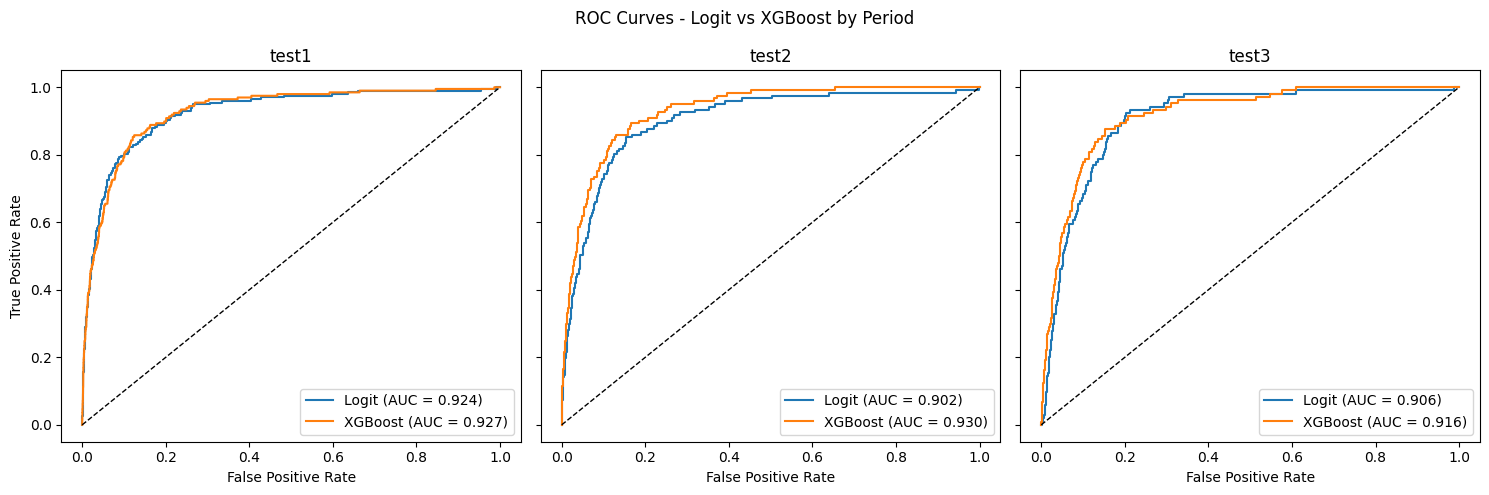

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, period in zip(axes, test_periods):
    for preds, name in [(logit_preds, "Logit"), (xgb_preds, "XGBoost")]:
        sub = preds[preds["period"] == period]
        fpr, tpr, _ = roc_curve(sub["y_true"], sub["pred_proba"])
        auc = summary.loc[
            (summary["model"] == name.lower()) & (summary["period"] == period), "auc_roc"
        ].values[0]
        ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_title(period)
    ax.set_xlabel("False Positive Rate")
    ax.legend()
axes[0].set_ylabel("True Positive Rate")
plt.suptitle("ROC Curves - Logit vs XGBoost by Period")
plt.tight_layout()
plt.savefig(FIG_DIR / "comparison_roc_overlay.png", dpi=150)
plt.show()

## 5. Calibration over time (Figure 3)

Predicted PD (both models) versus the realized default rate, by fiscal year. The right axis rescales the left (rate) into an approximate annual default count for context; all three plotted series are on the left (rate) axis.

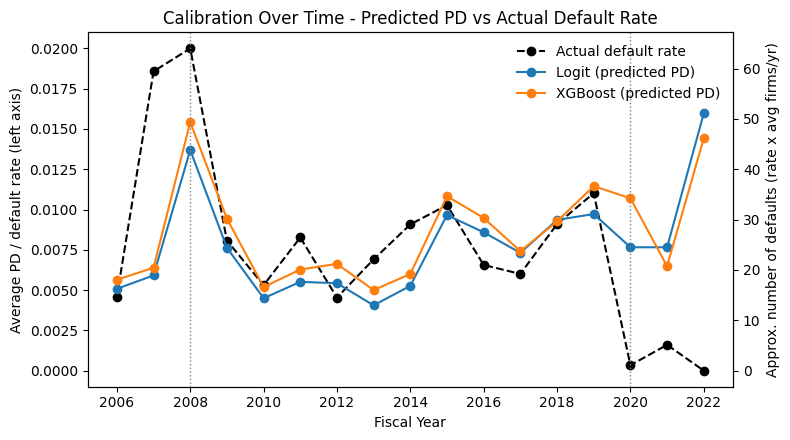

In [7]:
actual_rate_by_year = logit_preds.groupby("fyear")["y_true"].mean()
logit_pd_by_year = logit_preds.groupby("fyear")["pred_proba"].mean()
xgb_pd_by_year = xgb_preds.groupby("fyear")["pred_proba"].mean()
n_by_year = logit_preds.groupby("fyear")["y_true"].count()

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(actual_rate_by_year.index, actual_rate_by_year.values,
         label="Actual default rate", color="black", linestyle="--", marker="o")
ax1.plot(logit_pd_by_year.index, logit_pd_by_year.values, label="Logit (predicted PD)", marker="o")
ax1.plot(xgb_pd_by_year.index, xgb_pd_by_year.values, label="XGBoost (predicted PD)", marker="o")
ax1.axvline(2008, color="gray", linestyle=":", linewidth=1)
ax1.axvline(2020, color="gray", linestyle=":", linewidth=1)
ax1.set_xlabel("Fiscal Year")
ax1.set_ylabel("Average PD / default rate (left axis)")
ax1.set_title("Calibration Over Time - Predicted PD vs Actual Default Rate")

# Secondary axis: same series rescaled to an approximate annual default count
ax2 = ax1.twinx()
ax2.set_ylabel("Approx. number of defaults (rate x avg firms/yr)")
y_lo, y_hi = ax1.get_ylim()
ax2.set_ylim(y_lo * n_by_year.mean(), y_hi * n_by_year.mean())

ax1.legend(loc="upper right", frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "calibration_time_series.png", dpi=150)
plt.show()

## 6. Expected loss over time (Figure 4)

Annual expected loss (\$B) from calibrated PD x EAD x LGD, LGD = 45%.

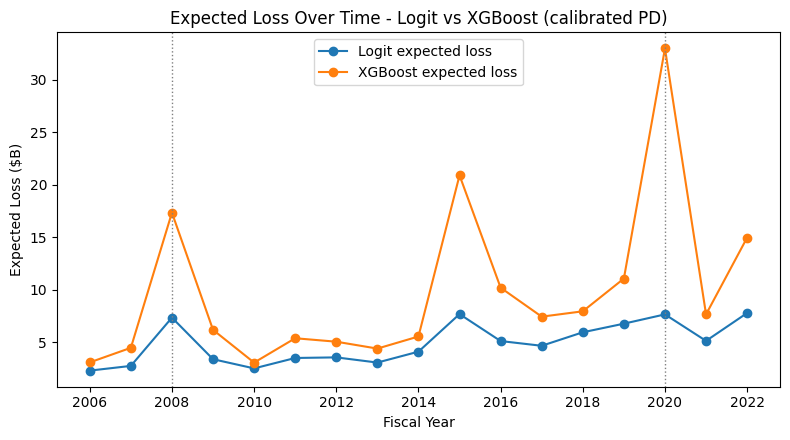

In [8]:
LGD = 0.45
logit_preds["EL"] = logit_preds["pred_proba"] * logit_preds["EAD"] * LGD
xgb_preds["EL"] = xgb_preds["pred_proba"] * xgb_preds["EAD"] * LGD

logit_el_by_year = logit_preds.groupby("fyear")["EL"].sum() / 1000
xgb_el_by_year = xgb_preds.groupby("fyear")["EL"].sum() / 1000

plt.figure(figsize=(8, 4.5))
plt.plot(logit_el_by_year.index, logit_el_by_year.values, label="Logit expected loss", marker="o")
plt.plot(xgb_el_by_year.index, xgb_el_by_year.values, label="XGBoost expected loss", marker="o")
plt.axvline(2008, color="gray", linestyle=":", linewidth=1)
plt.axvline(2020, color="gray", linestyle=":", linewidth=1)
plt.xlabel("Fiscal Year")
plt.ylabel("Expected Loss ($B)")
plt.title("Expected Loss Over Time - Logit vs XGBoost (calibrated PD)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "expected_loss_time_series.png", dpi=150)
plt.show()

## 7. Pseudo-\(R^2\) vs the Campbell (2008) benchmark (diagnostic)

Reference comparison against Campbell, Hilscher & Szilagyi (2008) Model 2 (0.312 in-sample, ~0.310 out-of-sample rolling). Their estimates are monthly with a broader failure definition, so this is directional, not a like-for-like match. Campbell's out-of-sample value is only available as a single rolling figure (shown at `test1`). Not used as a paper figure.

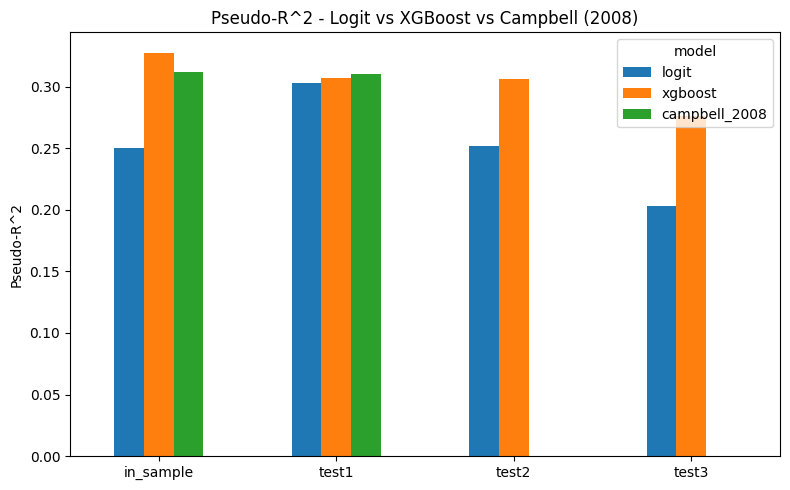

model,logit,xgboost,campbell_2008
period,,,
in_sample,0.2503,0.3277,0.312
test1,0.3030,0.3067,0.310
test2,0.2519,0.3060,NaN
test3,0.2030,0.2758,NaN


In [9]:
campbell = {"in_sample": 0.312, "test1": 0.310, "test2": np.nan, "test3": np.nan}

r2_table = summary.pivot(index="period", columns="model", values="pseudo_r2").reindex(period_order)
r2_table["campbell_2008"] = [campbell[p] for p in period_order]

ax = r2_table.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("Pseudo-R^2")
ax.set_title("Pseudo-R^2 - Logit vs XGBoost vs Campbell (2008)")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "comparison_pseudo_r2.png", dpi=150)
plt.show()
r2_table.round(4)

## 8. Calibration within windows: stress vs. ordinary years (Table 6)
 
Splits each test window into years of acute macro-financial stress and the remaining
years. This is the exercise behind Table 6: the window-level ratios in Table 5 are
blends of a well-calibrated ordinary-year subsample and a badly miscalibrated stress
subsample, not a uniform property of any window.
 
The 2020--2022 row rests on roughly five to six realized default events, so its ratio
is directional rather than a precise point estimate.

In [10]:
STRESS_YEARS = {
    "test1": {2007, 2008},          # global financial crisis
    "test2": set(),                 # no stress year falls inside this window
    "test3": {2020, 2021, 2022},    # COVID-19 and its immediate aftermath
}
ORDINARY_YEARS = {
    "test1": {2006, 2009, 2010},
    "test2": {2011, 2012, 2013, 2014, 2015},
    "test3": {2016, 2017, 2018, 2019},
}
 
 
def calibration_ratio(preds, period, years):
    """Average predicted PD, realized rate, and their ratio for a subset of years."""
    sub = preds[(preds["period"] == period) & (preds["fyear"].isin(years))]
    if sub.empty:
        return np.nan, np.nan, np.nan
    avg_pd = sub["pred_proba"].mean()
    realized = sub["y_true"].mean()
    return avg_pd, realized, avg_pd / realized
 
 
rows = []
for period in test_periods:
    for label, year_map in [("stress", STRESS_YEARS), ("ordinary", ORDINARY_YEARS)]:
        years = year_map[period]
        if not years:
            continue
        for model_name, preds in [("Dynamic logit", logit_preds), ("XGBoost", xgb_preds)]:
            avg_pd, realized, ratio = calibration_ratio(preds, period, years)
            rows.append({
                "period": period, "years": label, "model": model_name,
                "avg_pred_pd": avg_pd, "realized_rate": realized, "ratio": ratio,
            })
 
stress_calibration = pd.DataFrame(rows).set_index(["period", "years", "model"]).round(4)
stress_calibration

avg_pred_pd  realized_rate    ratio
period years    model                                             
test1  stress   Dynamic logit       0.0098         0.0193   0.5068
                XGBoost             0.0109         0.0193   0.5638
       ordinary Dynamic logit       0.0057         0.0060   0.9620
                XGBoost             0.0067         0.0060   1.1318
test2  ordinary Dynamic logit       0.0060         0.0078   0.7663
                XGBoost             0.0070         0.0078   0.8897
test3  stress   Dynamic logit       0.0107         0.0006  17.1153
                XGBoost             0.0107         0.0006  17.1153
       ordinary Dynamic logit       0.0087         0.0082   1.0714
                XGBoost             0.0094         0.0082   1.1522

### Discrimination on ordinary years only
 
Recomputes the discrimination metrics and the DeLong test after dropping the stress
years. Excluding them does **not** make the AUC-ROC edge significant outside
2011--2015, so the narrow discrimination gap is not an artifact of crisis-year noise.
AUC-PR is the exception: it improves materially in `test3` once 2020--2022 is dropped,
because that subsample is an extreme rare-event slice that mechanically depresses
precision-recall for both models.

In [11]:
def evaluate_subset(y_true, pred_proba):
    ks = ks_2samp(pred_proba[y_true == 1], pred_proba[y_true == 0]).statistic
    return {
        "auc_roc": roc_auc_score(y_true, pred_proba),
        "auc_pr": average_precision_score(y_true, pred_proba),
        "ks": ks,
    }
 
 
rows = []
for period in test_periods:
    years = ORDINARY_YEARS[period]
    logit_sub = logit_preds[(logit_preds["period"] == period) & (logit_preds["fyear"].isin(years))]
    xgb_sub = xgb_preds[(xgb_preds["period"] == period) & (xgb_preds["fyear"].isin(years))]
 
    y = logit_sub["y_true"].values
    p_logit = logit_sub["pred_proba"].values
    p_xgb = xgb_sub["pred_proba"].values
 
    m_logit = evaluate_subset(y, p_logit)
    m_xgb = evaluate_subset(y, p_xgb)
    _, _, z, delong_p = delong_test(y, p_logit, p_xgb)
 
    rows.append({"period": period, "model": "Dynamic logit", **m_logit, "delong_p": np.nan})
    rows.append({"period": period, "model": "XGBoost", **m_xgb, "delong_p": delong_p})
 
ordinary_year_metrics = pd.DataFrame(rows).set_index(["period", "model"]).round(4)
ordinary_year_metrics

auc_roc  auc_pr      ks  delong_p
period model                                           
test1  Dynamic logit   0.9115  0.1268  0.7146       NaN
       XGBoost         0.9163  0.1303  0.7810    0.6310
test2  Dynamic logit   0.9017  0.0973  0.6976       NaN
       XGBoost         0.9295  0.1481  0.7302    0.0014
test3  Dynamic logit   0.9097  0.0655  0.7262       NaN
       XGBoost         0.9227  0.0940  0.7400    0.1133